In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("/content/Fraud Detection Dataset.csv")
df.head(2)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [4]:
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [5]:
df.shape

(51000, 12)

In [6]:
##Checking for Missing Observations
df.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,2520
Transaction_Type,0
Time_of_Transaction,2552
Device_Used,2473
Location,2547
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0


In [7]:
#Checking Missing Values
features=[i for i in df.columns if df[i].isnull().sum()>=1]
for j in features:
    print(j,np.round(df[j].isnull().mean()*100,5),'% missing values')

Transaction_Amount 4.94118 % missing values
Time_of_Transaction 5.00392 % missing values
Device_Used 4.84902 % missing values
Location 4.99412 % missing values
Payment_Method 4.84118 % missing values


In [8]:
#Replacing null values with the median for numerical features and mode for categorical features
df['Transaction_Amount'] = df['Transaction_Amount'].fillna(df['Transaction_Amount'].median())
df['Time_of_Transaction'] = df['Time_of_Transaction'].fillna(df['Time_of_Transaction'].median())
df['Device_Used'] = df['Device_Used'].fillna(df['Device_Used'].mode()[0])
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])
df['Payment_Method'] = df['Payment_Method'].fillna(df['Payment_Method'].mode()[0])


In [9]:
df.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,0
Transaction_Type,0
Time_of_Transaction,0
Device_Used,0
Location,0
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0


In [10]:
#Removing insignificant Features
df.drop(['Transaction_ID','User_ID'],axis=1,inplace=True)

In [11]:
##To check all unique values
df['Payment_Method'].value_counts()

,count
Payment_Method,
UPI,14356
Debit Card,11802
Net Banking,11666
Credit Card,11646
Invalid Method,1530


In [12]:
## get all the numeric features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))
num_features

Num of Numerical Features : 6


['Transaction_Amount',
 'Time_of_Transaction',
 'Previous_Fraudulent_Transactions',
 'Account_Age',
 'Number_of_Transactions_Last_24H',
 'Fraudulent']

In [13]:
##get all the categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 4


In [14]:
num_features1=num_features.remove('Fraudulent')

In [15]:
##Discrete Features
disc_feat=[features for features in num_features if len(df[features].unique())<=25 ]
print(len(disc_feat))

3


In [16]:
##Continuous Features
cont_feat=[features for features in num_features if features not in disc_feat ]
print(len(cont_feat))

2


In [17]:
df.shape

(51000, 10)

MACHINE LEARNING TRAINING

In [18]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score,roc_curve,recall_score,f1_score,precision_score,accuracy_score


In [19]:
y_old=df['Fraudulent']  #Dependent Features
x_old=df.drop('Fraudulent',axis=1) #Independent Features
x_old.head(2)


,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method
0,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card
1,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card


In [20]:
#Splitting BEFORE any encoding/scaling/SMOTE so nothing from the test set leaks into training
x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    x_old, y_old, test_size=0.3, random_state=42, stratify=y_old
)
print('Train shape:', x_train_raw.shape, ' Test shape:', x_test_raw.shape)


Train shape: (35700, 9)  Test shape: (15300, 9)


In [21]:
cat_features = x_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
num_features1 = x_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    [
         ("OneHotEncoder", oh_transformer, cat_features),  #OneHot Encoding for categorical features
          ("StandardScaler", numeric_transformer, num_features1) #Normalisation of Numerical Features
    ]
)


In [22]:
#Fit the preprocessor on TRAIN ONLY, then transform both train and test with the fitted preprocessor
x_train = preprocessor.fit_transform(x_train_raw)
x_test = preprocessor.transform(x_test_raw)


In [23]:
y_train.value_counts()

,count
Fraudulent,
0,33943
1,1757


In [24]:
##As it is a severely imbalanced dataset - apply SMOTE to the TRAINING fold only.
##The test set (x_test, y_test) is left untouched and stays imbalanced/real.
sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)


In [25]:
y_train_res.value_counts()

,count
Fraudulent,
0,33943
1,33943


In [26]:
models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":XGBClassifier(random_state=42, eval_metric='logloss'),
    "KNeighborsClassifier":KNeighborsClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train_res, y_train_res) # Train on the SMOTE-resampled TRAINING data only

    # Make predictions
    y_train_pred = model.predict(x_train_res)
    y_test_pred = model.predict(x_test) # Evaluate on the untouched, original TEST data

    # Training set performance
    model_train_accuracy = accuracy_score(y_train_res, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train_res, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train_res, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train_res, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train_res, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))

    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))



    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))


    print('='*35)
    print('\n')


Logistic Regression
Model performance for Training set
- Accuracy: 0.5433
- F1 score: 0.5429
- Precision: 0.5458
- Recall: 0.5160
- Roc Auc Score: 0.5433
----------------------------------
Model performance for Test set
- Accuracy: 0.5626
- F1 score: 0.6814
- Precision: 0.0515
- Recall: 0.4529
- Roc Auc Score: 0.5106


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8919
- F1 score: 0.9001
- Precision: 0.0681
- Recall: 0.0943
- Roc Auc Score: 0.5137


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9501
- F1 score: 0.9293
- Precision: 0.4138
- Recall: 0.0319
- Roc Auc Score: 0.5148


XGBoost
Model performance for Training set
- Accu

In [27]:
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "sqrt", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}
xgb_params = {"n_estimators": [100, 200, 500, 1000],
              "max_depth": [3, 5, 7, 10],
              "learning_rate": [0.01, 0.05, 0.1, 0.2],
              "subsample": [0.7, 0.8, 1.0],
              "colsample_bytree": [0.7, 0.8, 1.0]}

In [28]:
randomcv_models = [
                   ("RF", RandomForestClassifier(random_state=42), rf_params),
                   ("XGB", XGBClassifier(random_state=42, eval_metric='logloss'), xgb_params)
                   ]


In [29]:
model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=16,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1,
                                   random_state=42)
    random.fit(x_train_res, y_train_res) # Tune using the resampled TRAINING data only
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits
---------------- Best Params for RF -------------------
{'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
---------------- Best Params for XGB -------------------
{'subsample': 0.8, 'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [30]:
#Fitting the tuned Random Forest model
rf_model=RandomForestClassifier(random_state=42, **model_param['RF'])
rf_model.fit(x_train_res,y_train_res)
rf_pred=rf_model.predict(x_test)
rf_proba=rf_model.predict_proba(x_test)[:,1]

#Performance Metrics
print("Random Forest")
print("Accuracy=",accuracy_score(y_test,rf_pred))
print("F1 Score=",f1_score(y_test,rf_pred))
print("Recall=",recall_score(y_test,rf_pred))
rf_auc = roc_auc_score(y_test, rf_proba)
print("ROC AUC=", rf_auc)


Random Forest
Accuracy= 0.9501307189542484
F1 Score= 0.059186189889025895
Recall= 0.03187250996015936
ROC AUC= 0.5347899207687935


In [31]:
#Fitting the tuned XGBoost model
xgb_model=XGBClassifier(random_state=42, eval_metric='logloss', **model_param['XGB'])
xgb_model.fit(x_train_res,y_train_res)
xgb_pred=xgb_model.predict(x_test)
xgb_proba=xgb_model.predict_proba(x_test)[:,1]

#Performance Metrics
print("XGBoost")
print("Accuracy=",accuracy_score(y_test,xgb_pred))
print("F1 Score=",f1_score(y_test,xgb_pred))
print("Recall=",recall_score(y_test,xgb_pred))
xgb_auc = roc_auc_score(y_test, xgb_proba)
print("ROC AUC=", xgb_auc)


XGBoost
Accuracy= 0.9512418300653595
F1 Score= 0.018421052631578946
Recall= 0.009296148738379814
ROC AUC= 0.4997730030360901


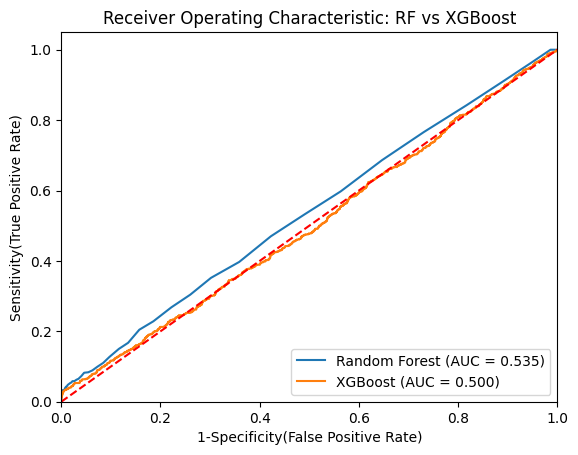

In [32]:
#ROC Curve comparison: Random Forest vs XGBoost
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

plt.plot(rf_fpr, rf_tpr, label='Random Forest (AUC = %0.3f)' % rf_auc)
plt.plot(xgb_fpr, xgb_tpr, label='XGBoost (AUC = %0.3f)' % xgb_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic: RF vs XGBoost')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show()


In [33]:
#Side-by-side comparison table
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],
    'F1 Score': [f1_score(y_test, rf_pred), f1_score(y_test, xgb_pred)],
    'Precision': [precision_score(y_test, rf_pred), precision_score(y_test, xgb_pred)],
    'Recall': [recall_score(y_test, rf_pred), recall_score(y_test, xgb_pred)],
    'ROC AUC': [rf_auc, xgb_auc]
})
comparison


,Model,Accuracy,F1 Score,Precision,Recall,ROC AUC
0,Random Forest,0.950131,0.059186,0.413793,0.031873,0.534790
1,XGBoost,0.951242,0.018421,1.000000,0.009296,0.499773
